# 11 — Disease courses: relapse vs monophasic, chronic mild vs severe, chronic vs RR

All five runs: transcriptome and **images** (runs 1–3 extracted and normalised with the notebook 02 method,
`scripts/02_normalise_all_runs.py`), lesion calls and states from notebook 10, daily clinical scores
(`data/clinical/`).

1. **Chronic mild vs severe.** The score data show severity is set at the first attack (SEVERE peaked at 3.5 and never
   recovered; MILD peaked 2.0–2.5). What does the tissue of a severe animal carry: more inflammation, or more
   *loss* (myelinating oligodendrocytes, neurons, ATP1A1 neuropil)?
2. **Relapse vs monophasic.** The first attack doesn't predict relapse clinically. (a) Same day, relapsed vs not:
   PEAK2/PEAK2_MILD vs MONOPHASIC (d31–33). (b) The pre-relapse window: REMISSION1 (d20–25) vs MONOPHASIC, both low
   score. (c) B cells, which accumulate after the first attack.
3. **Chronic vs RR at matched state.** PEAK1 chronic vs PEAK1 RR (both d13–18, score ~3). Different models (MOG35–55
   vs PLP139–151, likely different strains) and runs, so these are descriptions, not causes.
4. **Damage memory, all runs.** Notebook 10's image pilot (runs 5/6: neuropil recovers and vimentin builds from peak to
   recovery within the same lesion state) is repeated with 13 more recovery animals.

Unit = animal. Small groups: effect sizes and every animal are shown; Mann–Whitney p values are descriptive.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
from scipy.stats import mannwhitneyu, spearmanr

from beyondboundaries import plotting

plotting.style()
SRC = "notebooks/11_disease_courses.ipynb"
OUT = ROOT / "results" / "11_disease_courses"
OUT.mkdir(parents=True, exist_ok=True)
RES10 = ROOT / "results" / "10_lesion_states"

GROUP = {"CFA": "control", "MOG CFA": "control", "PLP CFA": "control", "NONSYMPTOM": "control",
         "OS1": "onset", "ONSET1": "onset", "ONSET2": "onset",
         "PEAK1": "peak", "PEAK2": "peak", "PEAK2_MILD": "peak", "PEAK3": "peak",
         "MILD16": "chronic late", "SEVERE16": "chronic late", "MILD30": "chronic late", "SEVERE30": "chronic late",
         "REMISSION1": "recovery", "REMISSION2": "recovery", "REMISSION2_LONG": "recovery", "MONOPHASIC": "recovery"}
COL = plotting.CATEGORICAL

In [2]:
a = ad.read_h5ad(ROOT / "data" / "RRMAP2_all_runs.h5ad", backed="r")
obs = a.obs[["sample_name", "meta_sample_id", "sample_id", "stage", "model", "Anno_L1_curated", "Anno_L2",
             "Curated_niche_state", "x_centroid", "y_centroid"]].copy()
a.file.close()
obs["stage"] = obs.stage.astype(str)
obs["arm"] = np.where(obs.model.astype(str).str.startswith("CHRONIC"), "chronic", "RR")
calls = pd.read_parquet(ROOT / "data" / "lesion10" / "lesion_calls.parquet")
obs = obs.join(calls)
axes10 = pd.read_parquet(ROOT / "data" / "lesion10" / "lesion_axes.parquet")
STATES = sorted(s for s in obs.lesion_state.unique() if s.startswith("S"))

clin = pd.read_csv(ROOT / "data" / "clinical" / "animal_course_metrics.csv", index_col=0)
animals = obs.groupby("sample_name", observed=True).agg(stage=("stage", "first"), arm=("arm", "first"),
                                                         run=("sample_id", lambda s: str(s.iloc[0]).split("_")[0]))
animals["group"] = animals.stage.map(GROUP)
animals = animals.join(clin[["onset_day", "first_peak", "nadir_after_first", "auc", "max_score", "max_weight_loss_pct",
                             "score", "day"]])
scored = obs.region_class.isin(["WM", "GM", "meninges"])
animals = animals.join(pd.crosstab(obs.loc[scored, "sample_name"], obs.loc[scored, "lesion_state"], normalize="index"))
animals["lesion share"] = 1 - animals["no lesion"]
print(len(animals), "animals")
animals.groupby(["arm", "stage"]).size().unstack(0)

67 animals


arm,RR,chronic
stage,,
CFA,NaN,2.0
MILD16,NaN,3.0
MILD30,NaN,5.0
MOG CFA,NaN,3.0
MONOPHASIC,4.0,NaN
NONSYMPTOM,NaN,5.0
ONSET1,2.0,NaN
ONSET2,2.0,NaN
OS1,NaN,5.0


### Per-animal tissue measures

- **Composition**: share of all cells per cell type (L1 + key L2 states). Loss measures are relative to the same
  region: MOL per WM cell, neurons per GM cell.
- **Lesion-axis means** in lesion tissue (notebook 10 axes, z vs control neighbourhoods).
- **Image readouts** (all runs, 18S-segmented cells): neuropil index (ATP1A1 in the 10 µm territory ÷ the piece's own
  non-lesion WM/GM), tissue vimentin and astrocyte vimentin (robust z within image), myeloid 18S texture (z within
  image). Medians per animal in lesion and in non-lesion tissue.

In [3]:
ct = obs.ctype.astype(str)
comp = pd.crosstab(obs.sample_name, ct, normalize="index")
wm = obs.region_class == "WM"
gm = obs.region_class == "GM"
loss = pd.DataFrame({
    "MOL per WM cell": (ct[wm] == "MOL").groupby(obs.sample_name[wm], observed=True).mean(),
    "neurons per GM cell": ct[gm].isin(["Exc neuron", "Inh neuron", "Chol neuron"]).groupby(obs.sample_name[gm],
                                                                                          observed=True).mean(),
})
les = obs.new_lesion == 1
axm = axes10[les].groupby(obs.sample_name[les], observed=True).mean().add_prefix("lesion axis: ")
animals = animals.join(comp.add_prefix("frac ")).join(loss).join(axm)

In [4]:
COLS = ["section_id", "meta_sample_id", "sample_name", "Anno_L1_curated", "segmentation_method", "x_centroid",
        "y_centroid", "bnd_terr_mean", "bnd_scale", "bnd_bg_local", "smavim_terr_mean", "smavim_cell_mean",
        "r18s_glcm_correlation", "run"]
fa = pd.read_parquet(ROOT / "data" / "features_norm_all.parquet", columns=COLS)
fa = fa[fa.segmentation_method == "Segmented by interior stain (18S)"]
fa = fa.join(obs[["lesion_state", "region_class"]], how="inner")
fa["les"] = fa.lesion_state.str.startswith("S")

# Each image holds 2-3 tissue pieces from different animals. In runs 1-3 pieces often touch (closest cells of two
# pieces 6-30 µm apart in 8 images; runs 5/6 >= 326 µm), so a border cell's territory / ring / local background
# partly measures the other animal's tissue. Neighbourhoods and lesion calls are per piece and unaffected; for
# image readouts, cells within 20 µm of another piece are excluded.
other = pd.Series(np.inf, index=obs.index)
for _, g in obs.groupby("sample_id", observed=True):
    xy = g[["x_centroid", "y_centroid"]].to_numpy()
    pc = g.meta_sample_id.astype(str).to_numpy()
    for p in np.unique(pc):
        m = pc == p
        if m.all():
            continue
        d, _ = cKDTree(xy[~m]).query(xy[m], k=1)
        other[g.index[m]] = d
fa["other_piece_um"] = other.reindex(fa.index).to_numpy()
print("cells within 20 µm of another piece, by run:",
      (fa.other_piece_um < 20).groupby(fa.run).mean().round(4).to_dict())
fa = fa[fa.other_piece_um >= 20]
print(fa.run.value_counts().sort_index().to_dict())


def image_z(s, by):
    med = s.groupby(by, observed=True).transform("median")
    mad = (s - med).abs().groupby(by, observed=True).transform("median") * 1.4826
    return (s - med) / mad.replace(0, np.nan)


fa["bnd_terr_raw"] = fa.bnd_terr_mean * fa.bnd_scale + fa.bnd_bg_local
key = fa.meta_sample_id.astype(str) + "|" + fa.region_class
ref = fa.bnd_terr_raw.where((fa.lesion_state == "no lesion") & fa.region_class.isin(["WM", "GM"])).groupby(key).agg(
    ["median", "count"])
ref = ref[ref["count"] >= 100]["median"]
fa["neuropil index"] = fa.bnd_terr_raw / key.map(ref)
fa["tissue vimentin (z)"] = image_z(fa.smavim_terr_mean, fa.section_id)
ast, mye = fa.Anno_L1_curated == "Astrocyte", fa.Anno_L1_curated == "Myeloid"
fa["astro vimentin (z)"] = image_z(fa.smavim_cell_mean.where(ast), fa.section_id).where(ast)
fa["myeloid 18S texture (z)"] = image_z(fa.r18s_glcm_correlation.where(mye), fa.section_id).where(mye)
READ = ["neuropil index", "tissue vimentin (z)", "astro vimentin (z)", "myeloid 18S texture (z)"]

img = {}
for tag, m in [("lesion", fa.les), ("non-lesion", ~fa.les & (fa.lesion_state == "no lesion"))]:
    g = fa[m].groupby("sample_name", observed=True)[READ]
    img[tag] = g.median().where(g.count() >= 50)
wm_les = fa.les & (fa.region_class == "WM")
img_wm = fa[wm_les].groupby("sample_name", observed=True)["neuropil index"].median().rename("WM lesion neuropil index")
animals = animals.join(img["lesion"].add_prefix("img lesion: ")).join(img["non-lesion"].add_prefix("img non-lesion: "))
animals = animals.join(img_wm)
animals.to_csv(OUT / "animal_table.csv")
animals.filter(like="img").notna().groupby(animals.run).sum()

cells within 20 µm of another piece, by run: {'run1': 0.0001, 'run2': 0.0003, 'run3': 0.0002, 'run5': 0.0, 'run6': 0.0}


{'run1': 258258, 'run2': 281119, 'run3': 302993, 'run5': 287014, 'run6': 193988}


,img lesion: neuropil index,img lesion: tissue vimentin (z),img lesion: astro vimentin (z),img lesion: myeloid 18S texture (z),img non-lesion: neuropil index,img non-lesion: tissue vimentin (z),img non-lesion: astro vimentin (z),img non-lesion: myeloid 18S texture (z)
run,,,,,,,,
run1,17,17,12,12,18,18,18,18
run2,12,12,10,10,12,12,12,12
run3,12,12,11,11,12,12,12,12
run5,17,17,15,15,19,19,19,19
run6,6,6,6,6,6,6,5,5


In [5]:
def compare(a_mask, b_mask, cols, la, lb):
    rows = []
    for c in cols:
        x, y = animals.loc[a_mask, c].dropna(), animals.loc[b_mask, c].dropna()
        if len(x) >= 2 and len(y) >= 2:
            rows.append({"measure": c, la: x.median(), lb: y.median(), f"n {la}": len(x), f"n {lb}": len(y),
                         "diff": y.median() - x.median(), "p": mannwhitneyu(x, y).pvalue})
    return pd.DataFrame(rows).set_index("measure")


def strip(ax, groups, col, labels, colors):
    for k, (m, lab, c) in enumerate(zip(groups, labels, colors)):
        v = animals.loc[m, col].dropna()
        ax.scatter(np.full(len(v), k) + np.random.default_rng(k).uniform(-0.1, 0.1, len(v)), v, s=22, color=c)
        ax.hlines(v.median(), k - 0.25, k + 0.25, color="black", lw=1.5)
    ax.set_xticks(range(len(groups)), labels)
    ax.set_title(col, fontsize=9)


MEAS = (["lesion share"] + STATES + ["MOL per WM cell", "neurons per GM cell", "frac B cell", "frac T cell", "frac MDM",
                                     "frac Reactive astro", "frac DAO"]
        + [c for c in animals if c.startswith("lesion axis: ")] + ["WM lesion neuropil index"]
        + [c for c in animals if c.startswith("img ")])

## 1. Chronic: mild vs severe
Clean contrast: MILD16 vs SEVERE16 (n = 3 + 3, d27–29, same run 5). Support: MILD30 (run 1) vs SEVERE30 (run 5),
batch-confounded.

In [6]:
st = animals.stage
c16 = compare(st == "MILD16", st == "SEVERE16", MEAS, "MILD16", "SEVERE16")
c30 = compare(st == "MILD30", st == "SEVERE30", MEAS, "MILD30", "SEVERE30")
both = c16[["MILD16", "SEVERE16", "diff", "p"]].join(c30[["MILD30", "SEVERE30", "diff"]], rsuffix=" (30)")
both["same direction"] = np.sign(both["diff"]) == np.sign(both["diff (30)"])
both.to_csv(OUT / "chronic_mild_vs_severe.csv")
both.round(3)

,MILD16,SEVERE16,diff,p,MILD30,SEVERE30,diff (30),same direction
measure,,,,,,,,
lesion share,0.283,0.518,0.235,0.1,0.298,0.424,0.126,True
S0: astro reactivity + oligo disease state,0.043,0.122,0.078,0.2,0.067,0.083,0.016,True
S1: monocyte-derived myeloid + microglia homeostasis loss,0.010,0.039,0.029,0.1,0.005,0.029,0.024,True
S2: fibrosis + myelinating oligo loss,0.101,0.110,0.009,0.7,0.126,0.196,0.070,True
S3: astro reactivity + MHC-II / IFN,0.033,0.073,0.039,0.1,0.019,0.035,0.016,True
S4: monocyte-derived myeloid + oligo disease state,0.012,0.055,0.043,0.1,0.017,0.034,0.017,True
S5: infiltration + microglia homeostasis loss,0.047,0.056,0.009,0.7,0.023,0.047,0.024,True
MOL per WM cell,0.151,0.083,-0.068,0.2,0.122,0.092,-0.030,True
neurons per GM cell,0.414,0.359,-0.055,0.1,0.375,0.398,0.023,False


Within all chronic-late animals (n = 13): does the score at sacrifice track **ongoing inflammation** or **loss**?
Spearman ρ of the sacrifice score (and of the first-peak height) with each measure.

In [7]:
cl = animals[animals.group == "chronic late"]
rho = pd.DataFrame({c: {"ρ score": spearmanr(cl.score, cl[c], nan_policy="omit").statistic,
                        "ρ first peak": spearmanr(cl.first_peak, cl[c], nan_policy="omit").statistic,
                        "n": cl[c].notna().sum()} for c in MEAS}).T
rho.to_csv(OUT / "chronic_late_score_correlations.csv")
rho.sort_values("ρ score").round(2)

/tmp/ipykernel_62756/3280587820.py:2: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho = pd.DataFrame({c: {"ρ score": spearmanr(cl.score, cl[c], nan_policy="omit").statistic,
/tmp/ipykernel_62756/3280587820.py:3: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  "ρ first peak": spearmanr(cl.first_peak, cl[c], nan_policy="omit").statistic,


,ρ score,ρ first peak,n
img lesion: tissue vimentin (z),-0.86,-0.72,13.0
img lesion: astro vimentin (z),-0.80,-0.62,13.0
lesion axis: microglia homeostasis loss,-0.72,-0.47,13.0
img non-lesion: myeloid 18S texture (z),-0.62,-0.43,13.0
lesion axis: oligo disease state,-0.56,-0.29,13.0
lesion axis: astro reactivity,-0.47,-0.43,13.0
img lesion: myeloid 18S texture (z),-0.46,-0.35,13.0
lesion axis: myelinating oligo loss,-0.46,-0.16,13.0
MOL per WM cell,-0.40,-0.54,13.0
lesion axis: fibrosis,-0.31,-0.48,13.0


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/11_disease_courses/chronic_mild_vs_severe.png')

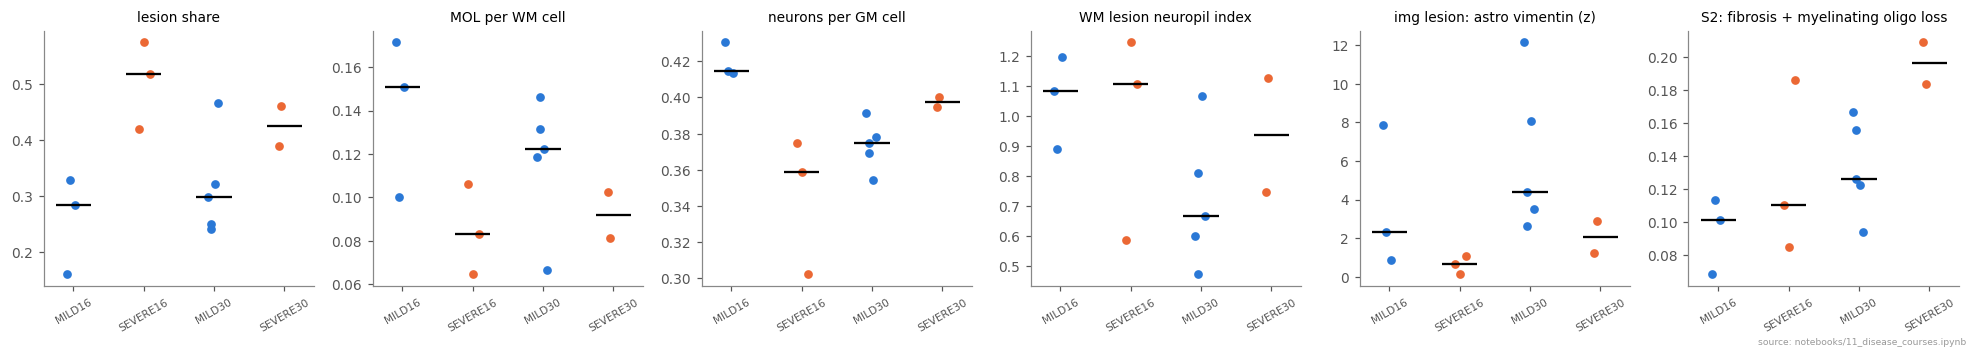

In [8]:
show = ["lesion share", "MOL per WM cell", "neurons per GM cell", "WM lesion neuropil index",
        "img lesion: astro vimentin (z)", [s for s in STATES if "fibrosis" in s][0]]
fig, axs = plt.subplots(1, len(show), figsize=(3 * len(show), 3.2))
for ax, c in zip(axs, show):
    strip(ax, [st == "MILD16", st == "SEVERE16", st == "MILD30", st == "SEVERE30"], c,
          ["MILD16", "SEVERE16", "MILD30", "SEVERE30"], [COL[0], COL[1], COL[0], COL[1]])
    ax.tick_params(axis="x", labelsize=7, rotation=30)
fig.tight_layout()
plotting.save_fig(fig, "chronic_mild_vs_severe", OUT, SRC)

## 2. Relapse vs monophasic
**(a) Same day, relapsed vs not**: PEAK2 + PEAK2_MILD vs MONOPHASIC (d31–33). **(b) Pre-relapse window**: REMISSION1
(d20–25; future unknown, most RR animals relapse) vs MONOPHASIC (never relapsed), both low score.

In [9]:
relapsed = st.isin(["PEAK2", "PEAK2_MILD"])
mono = st == "MONOPHASIC"
rem1 = st == "REMISSION1"
ca = compare(mono, relapsed, MEAS + ["first_peak", "nadir_after_first", "auc", "max_weight_loss_pct"],
             "MONOPHASIC", "PEAK2/2_MILD")
cb = compare(mono, rem1, MEAS + ["first_peak", "nadir_after_first", "auc", "max_weight_loss_pct"],
             "MONOPHASIC", "REMISSION1")
ca.to_csv(OUT / "monophasic_vs_relapsed.csv")
cb.to_csv(OUT / "monophasic_vs_remission1.csv")
ca.sort_values("p").round(3).head(15)

,MONOPHASIC,PEAK2/2_MILD,n MONOPHASIC,n PEAK2/2_MILD,diff,p
measure,,,,,,
lesion share,0.348,0.682,4,4,0.333,0.029
lesion axis: lipid-assoc. myeloid,5.869,7.372,4,4,1.503,0.029
frac Reactive astro,0.048,0.058,4,4,0.010,0.029
neurons per GM cell,0.401,0.334,4,4,-0.067,0.029
S0: astro reactivity + oligo disease state,0.061,0.128,4,4,0.067,0.057
auc,20.812,30.625,4,4,9.812,0.057
lesion axis: monocyte-derived myeloid,2.087,3.809,4,4,1.722,0.114
frac MDM,0.006,0.048,4,4,0.042,0.114
S4: monocyte-derived myeloid + oligo disease state,0.052,0.132,4,4,0.080,0.114


In [10]:
cb.sort_values("p").round(3).head(15)

,MONOPHASIC,REMISSION1,n MONOPHASIC,n REMISSION1,diff,p
measure,,,,,,
nadir_after_first,0.250,0.750,4,5,0.500,0.030
frac B cell,0.009,0.022,4,5,0.013,0.032
lesion axis: oligo disease state,1.966,1.397,4,5,-0.569,0.063
img non-lesion: myeloid 18S texture (z),-0.184,-0.336,4,5,-0.152,0.063
lesion share,0.348,0.532,4,5,0.184,0.111
img lesion: tissue vimentin (z),1.866,0.120,4,5,-1.746,0.111
img lesion: astro vimentin (z),3.343,1.065,4,5,-2.277,0.111
img lesion: myeloid 18S texture (z),0.095,-0.026,4,5,-0.121,0.111
neurons per GM cell,0.401,0.368,4,5,-0.033,0.190


**(c) B cells.** Share of B cells per stage, where they sit (meninges vs parenchyma), and how many are in aggregates
(≥ 5 B cells among their 15 nearest cells).

In [11]:
bc = obs[ct == "B cell"]
agg = pd.Series(False, index=bc.index)
for _, g in obs.groupby("meta_sample_id", observed=True):
    b = g[g.ctype == "B cell"]
    if len(b) < 5:
        continue
    _, nn = cKDTree(g[["x_centroid", "y_centroid"]].to_numpy()).query(b[["x_centroid", "y_centroid"]].to_numpy(), k=16)
    isb = (g.ctype == "B cell").to_numpy()
    agg[b.index] = isb[nn[:, 1:]].sum(1) >= 5
bstat = pd.DataFrame({
    "B cells per 1000 cells": comp.get("B cell", 0) * 1000,
    "B cells in meninges (share)": (bc.region_class == "meninges").groupby(bc.sample_name, observed=True).mean(),
    "B cells in aggregates (share)": agg.groupby(bc.sample_name, observed=True).mean(),
}).join(animals[["arm", "stage", "group"]])
bstat.to_csv(OUT / "b_cells_per_animal.csv")
bstat.groupby(["arm", "stage"])[["B cells per 1000 cells", "B cells in meninges (share)",
                                 "B cells in aggregates (share)"]].median().round(3)

B cells per 1000 cells  B cells in meninges (share)  \
arm     stage                                                                  
RR      MONOPHASIC                        9.061                        0.658   
        ONSET1                            0.221                        0.167   
        ONSET2                            1.269                        0.184   
        PEAK1                            13.816                        0.164   
        PEAK2                            10.741                        0.323   
        PEAK2_MILD                       24.508                        0.545   
        PEAK3                            19.408                        0.580   
        PLP CFA                           0.232                        0.500   
        REMISSION1                       21.572                        0.331   
        REMISSION2                        8.621                        0.583   
        REMISSION2_LONG                   4.995                        0.897   
chronic CFA                               0.225                        0.333   
        MILD16                            6.293                        0.850   
        MILD30                            1.134                        0.571   
        MOG CFA                           0.067                        0.500   
        NONSYMPTOM                        0.109                        0.083   
        OS1                               0.910                        0.370   
        PEAK1                             2.735                        0.262   
        SEVERE16                          7.759                        0.557   
        SEVERE30                          7.179                        0.898   

                         B cells in aggregates (share)  
arm     stage                                           
RR      MONOPHASIC                               0.306  
        ONSET1                                   0.000  
        ONSET2                                   0.219  
        PEAK1                                    0.263  
        PEAK2                                    0.330  
        PEAK2_MILD                               0.527  
        PEAK3                                    0.488  
        PLP CFA                                  0.000  
        REMISSION1                               0.552  
        REMISSION2                               0.425  
        REMISSION2_LONG                          0.397  
chronic CFA                                      0.000  
        MILD16                                   0.102  
        MILD30                                   0.000  
        MOG CFA                                  0.000  
        NONSYMPTOM                               0.000  
        OS1                                      0.000  
        PEAK1                                    0.000  
        SEVERE16                                 0.427  
        SEVERE30                                 0.316

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/11_disease_courses/b_cells_by_stage.png')

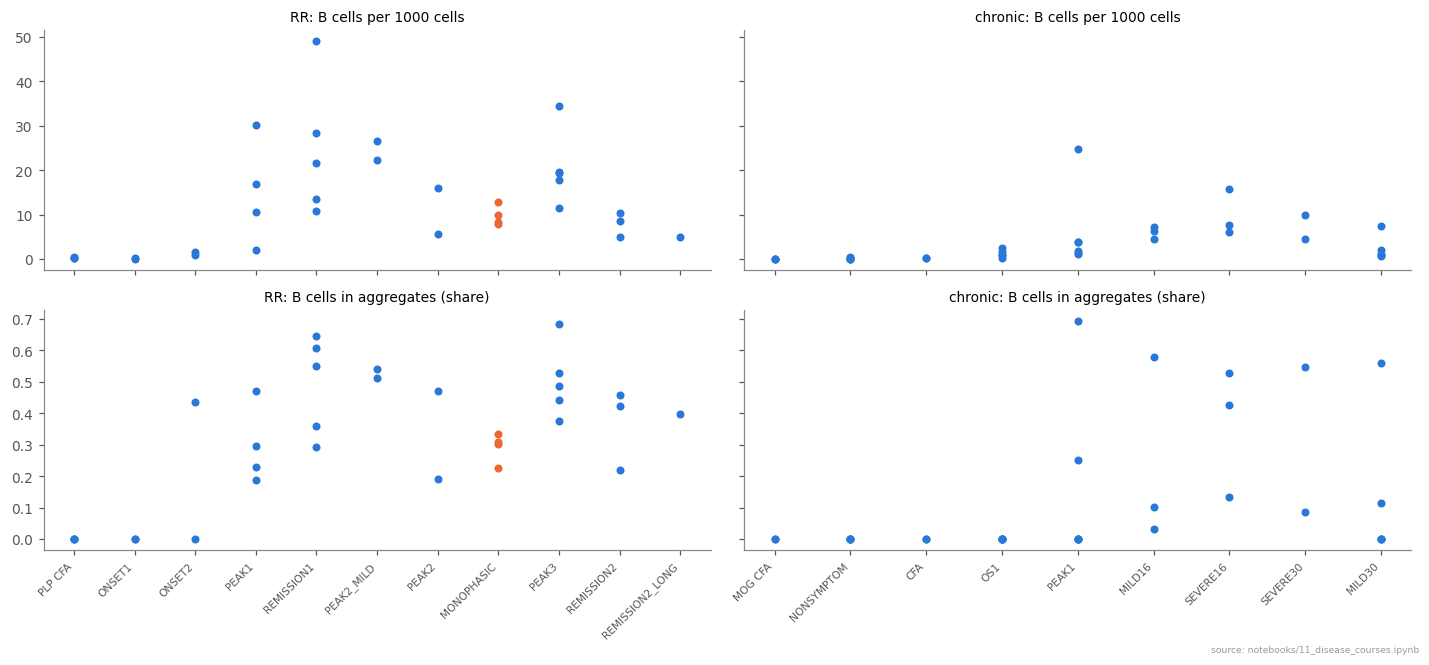

In [12]:
RR_ORDER = ["PLP CFA", "ONSET1", "ONSET2", "PEAK1", "REMISSION1", "PEAK2_MILD", "PEAK2", "MONOPHASIC", "PEAK3",
            "REMISSION2", "REMISSION2_LONG"]
CH_ORDER = ["MOG CFA", "NONSYMPTOM", "CFA", "OS1", "PEAK1", "MILD16", "SEVERE16", "SEVERE30", "MILD30"]
fig, axs = plt.subplots(2, 2, figsize=(13, 6), sharey="row")
for j, (arm, order) in enumerate([("RR", RR_ORDER), ("chronic", CH_ORDER)]):
    for i, c in enumerate(["B cells per 1000 cells", "B cells in aggregates (share)"]):
        ax = axs[i, j]
        for k, s in enumerate(order):
            v = bstat[(bstat.arm == arm) & (bstat.stage == s)][c].dropna()
            ax.scatter(np.full(len(v), k), v, s=18, color=COL[1] if s in ("MONOPHASIC",) else COL[0])
        ax.set_xticks(range(len(order)), order if i == 1 else [], rotation=45, ha="right", fontsize=7)
        ax.set_title(f"{arm}: {c}", fontsize=9)
fig.tight_layout()
plotting.save_fig(fig, "b_cells_by_stage", OUT, SRC)

## 3. Chronic vs RR at matched state (PEAK1, d13–18, score ~3)

In [13]:
pk = st == "PEAK1"
c3 = compare(pk & (animals.arm == "chronic"), pk & (animals.arm == "RR"),
             MEAS + [c for c in animals if c.startswith("frac ")] + ["first_peak", "onset_day", "max_weight_loss_pct"],
             "chronic PEAK1", "RR PEAK1")
c3 = c3[~c3.index.duplicated()]
c3.to_csv(OUT / "chronic_vs_rr_peak1.csv")
c3.sort_values("p").round(3).head(20)

,chronic PEAK1,RR PEAK1,n chronic PEAK1,n RR PEAK1,diff,p
measure,,,,,,
S4: monocyte-derived myeloid + oligo disease state,0.169,0.256,6,4,0.088,0.010
lesion axis: lipid-assoc. myeloid,9.072,5.405,6,4,-3.667,0.010
frac CAM,0.015,0.009,6,4,-0.006,0.019
img lesion: astro vimentin (z),2.590,0.182,6,4,-2.408,0.038
frac other,0.013,0.016,6,4,0.003,0.038
img non-lesion: tissue vimentin (z),-0.082,-0.188,6,4,-0.106,0.038
img non-lesion: astro vimentin (z),0.582,-0.433,6,3,-1.016,0.048
lesion share,0.871,0.933,6,4,0.062,0.114
S2: fibrosis + myelinating oligo loss,0.027,0.011,6,4,-0.017,0.114


In [14]:
lr = obs[(obs.new_lesion == 1) & obs.sample_name.isin(animals[pk].index)]
where = pd.crosstab(lr.sample_name, lr.region_class, normalize="index").join(animals.arm)
where.groupby("arm").median().round(3)

,GM,WM,meninges
arm,,,
RR,0.364,0.597,0.051
chronic,0.320,0.631,0.052


## 4. Damage memory with all runs: the same lesion state at peak vs in recovery

In [15]:
pa = fa.groupby(["sample_name", "lesion_state"], observed=True)[READ].median()
pa["n"] = fa.groupby(["sample_name", "lesion_state"], observed=True).size()
pa = pa[pa.n >= 50].reset_index().join(animals[["group", "arm", "stage", "run"]], on="sample_name")
pa.to_csv(OUT / "image_readouts_per_animal_state.csv", index=False)
rows = []
for s in STATES + ["no lesion"]:
    for r in READ:
        p = pa[(pa.lesion_state == s) & (pa.group == "peak")][r].dropna()
        q = pa[(pa.lesion_state == s) & (pa.group == "recovery")][r].dropna()
        if len(p) >= 3 and len(q) >= 3:
            rows.append(dict(state=s, readout=r, peak=p.median(), recovery=q.median(), n_peak=len(p), n_rec=len(q),
                             p=mannwhitneyu(p, q).pvalue))
dm = pd.DataFrame(rows)
o = dm.p.sort_values(ascending=False)
dm["q (BH)"] = (o * len(o) / o.rank()).cummin().clip(upper=1).reindex(dm.index)
dm.to_csv(OUT / "peak_vs_recovery_within_state_all_runs.csv", index=False)
dm.round(3)

,state,readout,peak,recovery,n_peak,n_rec,p,q (BH)
0,S0: astro reactivity + oligo disease state,neuropil index,1.027,0.916,19,13,0.378,0.705
1,S0: astro reactivity + oligo disease state,tissue vimentin (z),-0.092,-0.006,19,13,0.009,0.127
2,S0: astro reactivity + oligo disease state,astro vimentin (z),0.158,1.138,19,13,0.055,0.308
3,S0: astro reactivity + oligo disease state,myeloid 18S texture (z),-0.091,-0.079,19,13,0.908,1.000
4,S1: monocyte-derived myeloid + microglia homeo...,neuropil index,0.786,1.026,19,11,0.132,0.396
5,S1: monocyte-derived myeloid + microglia homeo...,tissue vimentin (z),3.344,7.659,19,11,0.156,0.396
6,S1: monocyte-derived myeloid + microglia homeo...,astro vimentin (z),3.126,4.520,19,11,0.439,0.767
7,S1: monocyte-derived myeloid + microglia homeo...,myeloid 18S texture (z),0.189,0.193,19,11,1.000,1.000
8,S2: fibrosis + myelinating oligo loss,neuropil index,0.922,1.065,19,13,0.071,0.310
9,S2: fibrosis + myelinating oligo loss,tissue vimentin (z),2.495,2.791,19,13,0.337,0.705


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/11_disease_courses/image_readouts_by_state_all_runs.png')

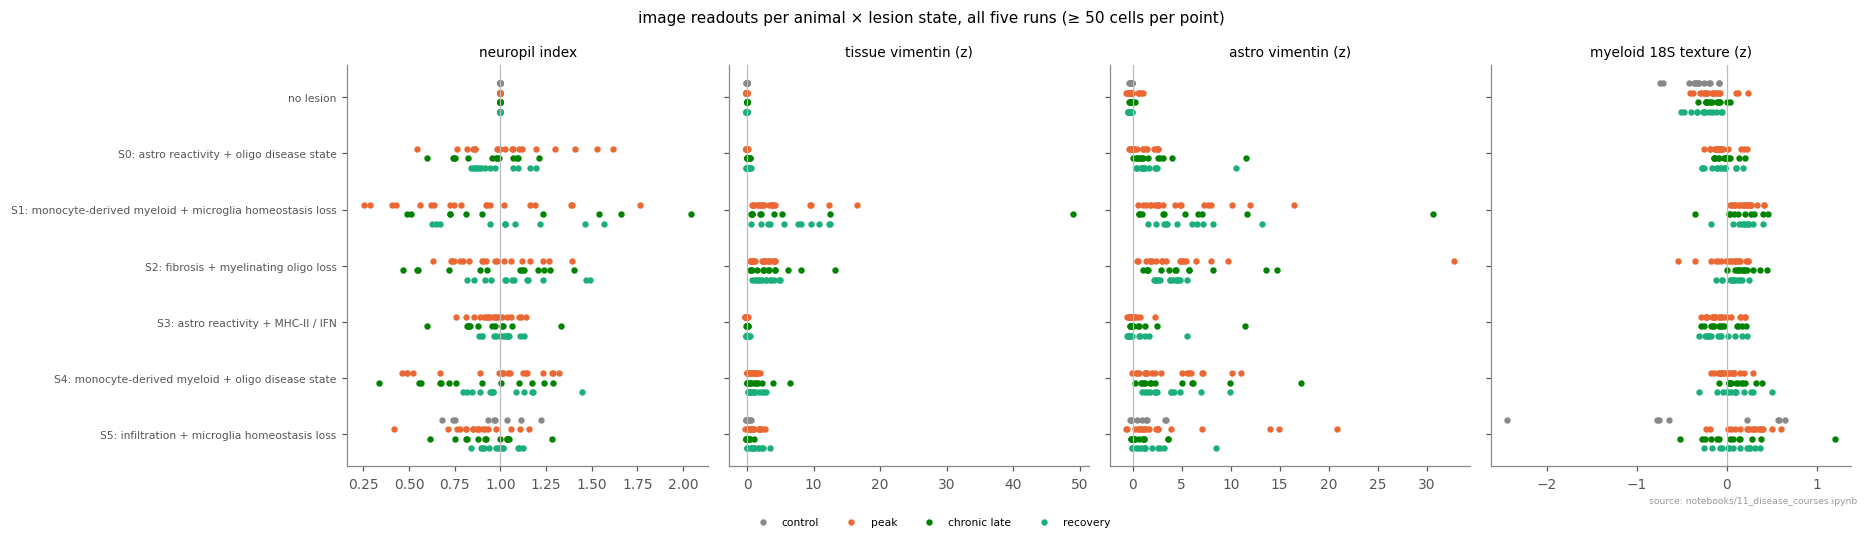

In [16]:
fig, axs = plt.subplots(1, len(READ), figsize=(17, 4.6), sharey=True)
show = ["no lesion"] + STATES
for ax, r in zip(axs, READ):
    for i, s in enumerate(show):
        for j, g in enumerate(["control", "peak", "chronic late", "recovery"]):
            v = pa[(pa.lesion_state == s) & (pa.group == g)][r].dropna()
            ax.scatter(v, np.full(len(v), i) + (j - 1.5) * 0.17, s=10, color=["#888888", COL[1], COL[5], COL[2]][j],
                       label=g if (i == 0 and r == READ[0]) else None)
    ax.set_title(r, fontsize=9)
    ax.axvline(1 if r == "neuropil index" else 0, color="#bbbbbb", lw=0.8)
axs[0].set_yticks(range(len(show)), show, fontsize=7)
axs[0].invert_yaxis()
fig.legend(fontsize=7, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.06))
fig.suptitle("image readouts per animal × lesion state, all five runs (≥ 50 cells per point)", fontsize=10)
fig.tight_layout()
plotting.save_fig(fig, "image_readouts_by_state_all_runs", OUT, SRC)

## Findings

> **1. Vimentin marks lesions that are being contained, and it is the one signal only the images give.** Astrocyte
> vimentin inside lesions (robust z within image; *Vim* is not on the panel) is higher wherever disease is
> resolving or milder, in every contrast: chronic MILD16 vs SEVERE16 2.3 vs 0.7 (same run; MILD30 vs SEVERE30
> 4.4 vs 2.0); MONOPHASIC vs REMISSION1 3.3 vs 1.1 (tissue vimentin 1.9 vs 0.1); chronic vs RR PEAK1 2.6 vs 0.2
> (p = 0.04); and within the same lesion state from peak to recovery (S0 0.16 → 1.14, p = 0.055; tissue vimentin in
> S0/S3 p = 0.009/0.005, q = 0.13). Among chronic-late animals, more lesion vimentin goes with a lower score
> (ρ = −0.80). Groups are small (3–19 animals) and nothing survives a strict correction; the consistency across
> independent contrasts is the evidence. The channel also carries αSMA.
>
> **2. Chronic severity: lesions that stayed active and unscarred.** At d27–41 severe animals still carry more lesion
> (0.52 vs 0.28; 0.42 vs 0.30) with more active monocyte-derived states (S1, S4), T cells and cellularity (same
> direction in both cohorts), and fewer myelinating oligodendrocytes in WM (0.08 vs 0.15 per WM cell); neuropil
> does not differ. Across all 13 chronic-late animals the strongest correlate of the score is **low lesion astrocyte
> vimentin (ρ = −0.80)**, then lesion share (0.58), T cells (0.47), cellularity (0.38); in run 5 alone (n = 8) the
> inflammation correlations are 0.77–0.89. (A first run of this notebook missed the MILD30 scores, a naming mismatch
> fixed in `scripts/clinical_metrics.py`.) The tissue-loss hypothesis is not supported.
>
> **3. Relapse: B cells.** RR animals accumulate B cells after the first attack and move them into aggregates and the
> meninges (per 1000 cells: PEAK1 14 → REMISSION1 22 → PEAK2_MILD 25 / PEAK3 19; aggregated share 0.26 → 0.55;
> meningeal share 0.16 at PEAK1 → 0.58–0.90 later). Never-relapsing MONOPHASIC animals have fewer B cells than
> REMISSION1 animals (9 vs 22, p = 0.03; aggregated 0.31 vs 0.55), recovered further after the first attack (nadir
> 0.25 vs 0.75, p = 0.03) and show more lesion vimentin (finding 1). The chronic arm has few B cells throughout (≤ 8).
> Same-day relapsed vs monophasic differences (lesion share 0.68 vs 0.35, lipid-associated myeloid, neuron loss) are
> what the relapse did, not its cause.
>
> **4. Chronic vs RR at the same peak** (both d13–18, score ~3; different models and runs): RR lesions are more
> monocyte-derived/oligo-damage (S4 0.26 vs 0.17, p = 0.01) with less lipid-associated myeloid signal (5.4 vs 9.1,
> p = 0.01), more B cells (14 vs 3 per 1000) and more weight loss (22 vs 14 %); chronic lesions have more astrocyte
> vimentin (above) and lower WM neuropil (0.43 vs 0.82, p = 0.13).
>
> **5. Damage memory, all runs** (19 peak vs 13 recovery animals): within the same lesion state, neuropil trends back
> towards normal (S1 0.79 → 1.03, S5 0.88 → 0.99 p = 0.02, S2 0.92 → 1.07) while vimentin builds (finding 1). This
> replicates the runs 5/6 pilot in direction; no single test survives BH (best q = 0.13).
>
> To check: lesion neuropil index > 1 in some chronic groups (e.g. MILD16 1.09) is at odds with notebook 06's WM
> lesion loss; the non-lesion reference (control-referenced calls, per piece × WM/GM) differs from notebook 06's and
> needs a direct comparison.